# 🔍 Semantic Plagiarism Detection System
### Using Pretrained Transformers + Neural Classifier (DNN)

**Objective:** Detect whether two text passages are plagiarized using semantic similarity — not keyword matching.

**Pipeline:** Data → Preprocessing → Sentence Embeddings → Feature Engineering → DNN Classifier → Evaluation → Baseline Comparison → Inference Demo


In [1]:
# Install required libraries (run once)
# !pip install sentence-transformers scikit-learn tensorflow pandas numpy matplotlib seaborn


In [9]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn sentence-transformers tensorflow


  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.me

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Libraries loaded ✓")

TensorFlow: 2.21.0
Libraries loaded ✓


---
## 📂 Section 1 — Load Dataset

The dataset contains pairs of texts (`source_text`, `plagiarized_text`) with binary labels:
- **1** = Plagiarized (paraphrase or rewrite of the source)
- **0** = Not Plagiarized (semantically unrelated)


In [28]:
df = pd.read_csv('dataset.csv', index_col=0)

# Rename columns for clarity
df = df.rename(columns={'source_text': 'text1', 'plagiarized_text': 'text2'})
df['label'] = df['label'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().rename({0: 'Not Plagiarized', 1: 'Plagiarized'}))
df.head(5)

Dataset shape: (370, 3)

Label distribution:
label
Plagiarized        187
Not Plagiarized    183
Name: count, dtype: int64


,text1,text2,label
0,Researchers have discovered a new species of b...,Scientists have found a previously unknown but...,1
1,The moon orbits the Earth in approximately 27....,Our natural satellite takes around 27.3 days t...,1
2,Water is composed of two hydrogen atoms and on...,H2O consists of 2 hydrogen atoms and 1 oxygen ...,1
3,The history of Rome dates back to 753 BC.,Rome has a long history that can be traced bac...,1
4,Pluto was once considered the ninth planet in ...,"In the past, Pluto was classified as the ninth...",1


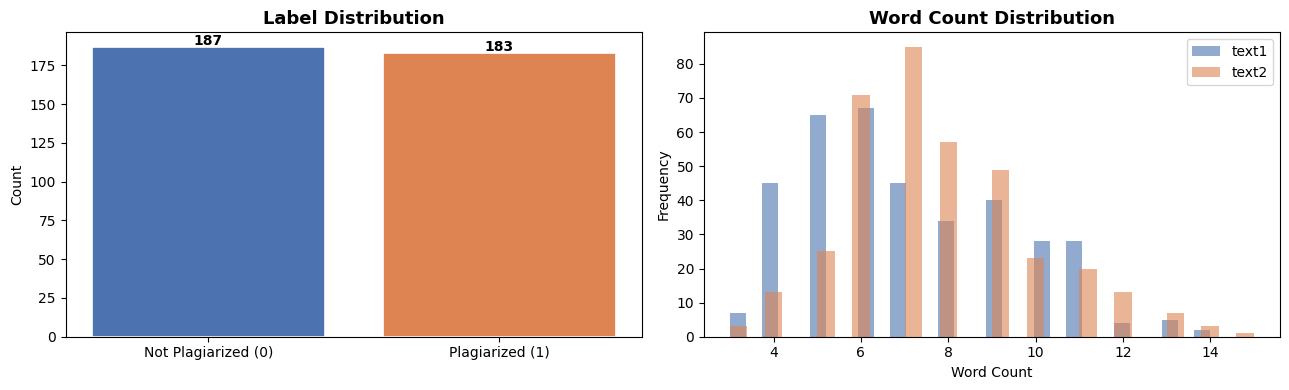

Avg text1 length: 7.0 words | Avg text2 length: 7.7 words


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Label distribution
counts = df['label'].value_counts()
axes[0].bar(['Not Plagiarized (0)', 'Plagiarized (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Text length distribution
df['len1'] = df['text1'].str.split().str.len()
df['len2'] = df['text2'].str.split().str.len()
axes[1].hist(df['len1'], bins=30, alpha=0.6, label='text1', color='#4C72B0')
axes[1].hist(df['len2'], bins=30, alpha=0.6, label='text2', color='#DD8452')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Avg text1 length: {df['len1'].mean():.1f} words | Avg text2 length: {df['len2'].mean():.1f} words")


---
## 🧹 Section 2 — Text Preprocessing

We apply **minimal preprocessing**:
- Lowercase
- Remove extra whitespace

> **Why minimal?** Transformers like `all-MiniLM-L6-v2` are pretrained on raw, natural text. They are sensitive to word forms and context — stemming/lemmatization would strip away meaning that the model uses to understand semantics.


In [30]:

def preprocess(text: str) -> str:
    """Lowercase and collapse whitespace. No stemming/lemmatization."""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text1'] = df['text1'].apply(preprocess)
df['text2'] = df['text2'].apply(preprocess)

print("Sample after preprocessing:")
print(f"  text1: {df['text1'].iloc[0]}")
print(f"  text2: {df['text2'].iloc[0]}")
print(f"  label: {df['label'].iloc[0]}")

Sample after preprocessing:
  text1: researchers have discovered a new species of butterfly in the amazon rainforest.
  text2: scientists have found a previously unknown butterfly species in the amazon jungle.
  label: 1


---
## 🧠 Section 3 — Sentence Embeddings (Transfer Learning)

We use `all-MiniLM-L6-v2` from `sentence-transformers`:
- Lightweight (22M parameters), fast, and high quality
- Produces **384-dimensional** dense vectors that capture **semantic meaning**
- Two sentences with similar meanings → similar vectors (high cosine similarity)


In [31]:
print("Loading sentence transformer model...")
encoder = SentenceTransformer('all-mpnet-base-v2')

texts1 = df['text1'].tolist()
texts2 = df['text2'].tolist()

print("Encoding text1...")
emb1 = encoder.encode(texts1, show_progress_bar=True, batch_size=32)
print("Encoding text2...")
emb2 = encoder.encode(texts2, show_progress_bar=True, batch_size=32)

print(f"\nEmbedding shape per text: {emb1.shape}  (samples × 768 dimensions)")

Loading sentence transformer model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2879.73it/s]


Encoding text1...


Batches: 100%|██████████| 12/12 [00:06<00:00,  1.79it/s]


Encoding text2...


Batches: 100%|██████████| 12/12 [00:07<00:00,  1.62it/s]


Embedding shape per text: (370, 768)  (samples × 768 dimensions)


---
## ⚙️ Section 4 — Feature Engineering

For each text pair we construct a rich feature vector:

| Feature | Shape | Captures |
|---|---|---|
| `emb1` | 384 | Absolute semantics of text1 |
| `emb2` | 384 | Absolute semantics of text2 |
| `\|emb1 - emb2\|` | 384 | Dimension-wise deviation |
| Cosine similarity | 1 | Overall directional similarity |

**Total feature size: 384×3 + 1 = 1153**

> The absolute difference highlights *where* the embeddings differ, while cosine similarity gives a single holistic score. Together they give the DNN rich signal to distinguish paraphrase from unrelated text.


In [32]:
def build_features(e1: np.ndarray, e2: np.ndarray) -> np.ndarray:
    """Concatenate [emb1, emb2, |emb1-emb2|, emb1*emb2, cosine_sim] for each pair."""
    abs_diff = np.abs(e1 - e2)                              # (N, 768)
    mult = e1 * e2                                          # (N, 768)
    cos = np.array([
        cos_sim([e1[i]], [e2[i]])[0][0] for i in range(len(e1))
    ]).reshape(-1, 1)                                        # (N, 1)
    return np.hstack([e1, e2, abs_diff, mult, cos])         # (N, 3073)

X = build_features(emb1, emb2)
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape:   {y.shape}")
print(f"Feature breakdown: 768 (emb1) + 768 (emb2) + 768 (|diff|) + 768 (mult) + 1 (cosine) = {X.shape[1]}")

Feature matrix shape: (370, 3073)
Label vector shape:   (370,)
Feature breakdown: 768 (emb1) + 768 (emb2) + 768 (|diff|) + 768 (mult) + 1 (cosine) = 3073


---
## ✂️ Section 5 — Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to preserve the label ratio across all sets.


In [33]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42, stratify=y_trainval
)

print(f"Train:      {X_train.shape[0]} samples  ({y_train.mean()*100:.1f}% plagiarised)")
print(f"Validation: {X_val.shape[0]} samples  ({y_val.mean()*100:.1f}% plagiarised)")
print(f"Test:       {X_test.shape[0]} samples  ({y_test.mean()*100:.1f}% plagiarised)")

# Feature scaling (important for DNNs)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print("\nFeatures scaled with StandardScaler ✓")


Train:      258 samples  (50.8% plagiarised)
Validation: 56 samples  (50.0% plagiarised)
Test:       56 samples  (50.0% plagiarised)

Features scaled with StandardScaler ✓


---
## 🏗️ Section 6 — DNN Classifier

Architecture:
```
Input (1153) → Dense(256, ReLU) → BN → Dropout(0.4)
             → Dense(128, ReLU) → BN → Dropout(0.3)
             → Dense(64,  ReLU) → Dropout(0.2)
             → Dense(1, Sigmoid)
```

- **BatchNormalization** stabilises training
- **Dropout** prevents overfitting on the small dataset
- **Sigmoid** output → probability of plagiarism


In [34]:
input_dim = X_train_s.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
], name='PlagiarismDNN')


model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "PlagiarismDNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,313 (6.64 MB)

 Trainable params: 1,739,777 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

---
## 🚀 Section 7 — Training

Callbacks:
- **EarlyStopping** (patience=10) — stops when val_loss stops improving
- **ReduceLROnPlateau** — halves LR when val_loss plateaus for 5 epochs


In [35]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=16,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.8140 - loss: 0.4345 - val_accuracy: 0.8750 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9690 - loss: 0.0874 - val_accuracy: 0.9107 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9690 - loss: 0.0606 - val_accuracy: 0.9286 - val_loss: 0.1855 - learning_rate: 0.0010
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0160 - val_accuracy: 0.9286 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.9464 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.9643 - val_loss: 0.1434 - learning_rate: 0.0010
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0077 - val_acc

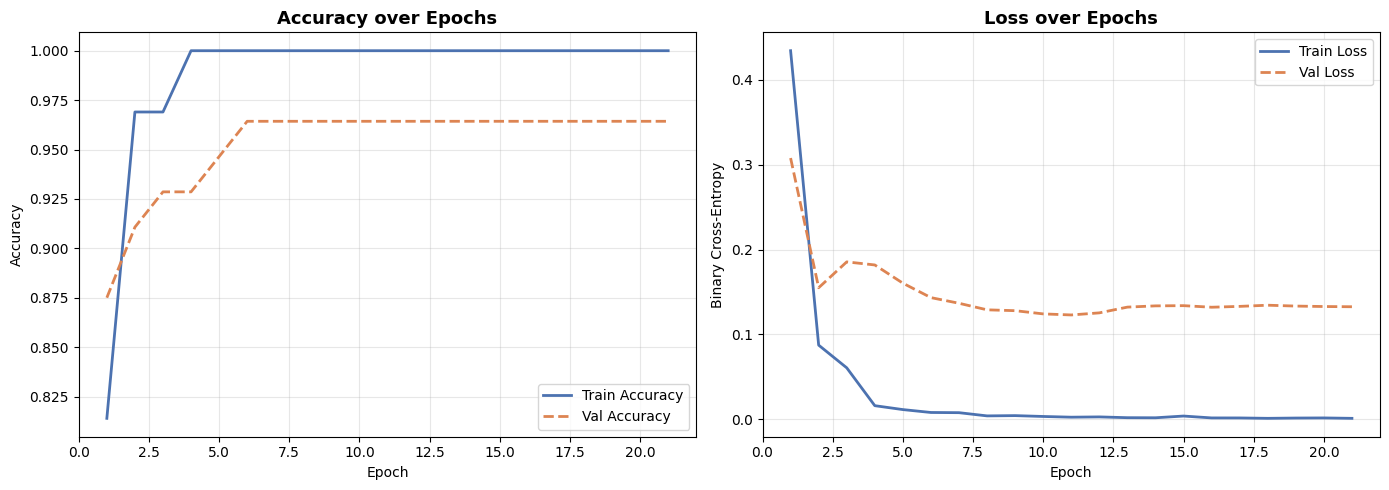

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy', color='#4C72B0', lw=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy',   color='#DD8452', lw=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss', color='#4C72B0', lw=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='#DD8452', lw=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📊 Section 8 — Evaluation

We evaluate on the **held-out test set** (never seen during training).


In [37]:
y_prob = model.predict(X_test_s).flatten()
y_pred = (y_prob >= 0.6).astype(int)

print("=" * 50)
print("        DNN Model — Test Set Results")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  F1 Score : {f1_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Plagiarised', 'Plagiarised']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
        DNN Model — Test Set Results
  Accuracy : 96.43%
  F1 Score : 96.55%

Classification Report:
                 precision    recall  f1-score   support

Not Plagiarised       1.00      0.93      0.96        28
    Plagiarised       0.93      1.00      0.97        28

       accuracy                           0.96        56
      macro avg       0.97      0.96      0.96        56
   weighted avg       0.97      0.96      0.96        56



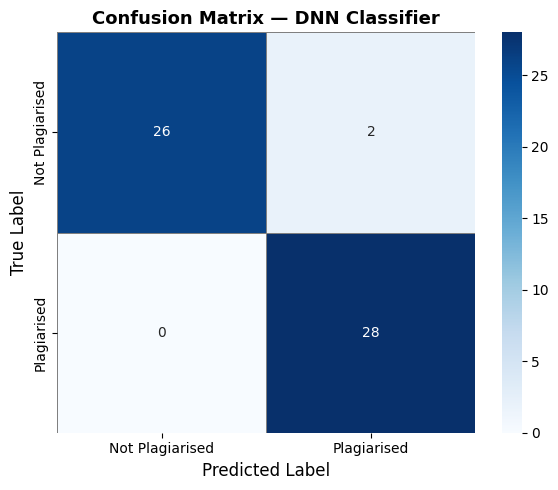

True Negatives: 26  |  False Positives: 2
False Negatives: 0  |  True Positives: 28


In [38]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Plagiarised', 'Plagiarised'],
            yticklabels=['Not Plagiarised', 'Plagiarised'],
            linewidths=0.5, linecolor='grey', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — DNN Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_dnn.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}  |  False Positives: {fp}")
print(f"False Negatives: {fn}  |  True Positives: {tp}")

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1, cv_acc = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    from sklearn.utils.class_weight import compute_class_weight
    cw = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)))

    m = Sequential([
        Dense(512, activation='relu', input_shape=(X_tr_s.shape[1],)),
        BatchNormalization(), Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(), Dropout(0.2),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_tr_s, y_tr, validation_split=0.1, epochs=60, batch_size=16,
          class_weight=cw, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
          verbose=0)

    y_pred_fold = (m.predict(X_te_s, verbose=0).flatten() >= 0.6).astype(int)
    cv_f1.append(f1_score(y_te, y_pred_fold))
    cv_acc.append(accuracy_score(y_te, y_pred_fold))
    print(f"Fold {fold+1}: Accuracy={cv_acc[-1]*100:.2f}%  F1={cv_f1[-1]*100:.2f}%")

print(f"\n5-Fold CV  →  Accuracy: {np.mean(cv_acc)*100:.2f}% ± {np.std(cv_acc)*100:.2f}%")
print(f"5-Fold CV  →  F1 Score: {np.mean(cv_f1)*100:.2f}% ± {np.std(cv_f1)*100:.2f}%")


Fold 1: Accuracy=91.89%  F1=91.89%
Fold 2: Accuracy=97.30%  F1=97.44%
Fold 3: Accuracy=93.24%  F1=93.51%
Fold 4: Accuracy=93.24%  F1=93.67%
Fold 5: Accuracy=94.59%  F1=94.44%

5-Fold CV  →  Accuracy: 94.05% ± 1.83%
5-Fold CV  →  F1 Score: 94.19% ± 1.82%


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# y_prob was already computed in the Test Results cell above
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold : {best_threshold:.4f}")
print(f"Best F1 at threshold: {f1_scores[best_idx]*100:.2f}%")

# Compare vs your current 0.6 threshold
y_pred_optimized = (y_prob >= best_threshold).astype(int)
print(f"\nWith threshold={best_threshold:.2f}:")
print(classification_report(y_test, y_pred_optimized, target_names=['Not Plagiarised', 'Plagiarised']))

Optimal threshold : 0.6733
Best F1 at threshold: 96.55%

With threshold=0.67:
                 precision    recall  f1-score   support

Not Plagiarised       1.00      0.93      0.96        28
    Plagiarised       0.93      1.00      0.97        28

       accuracy                           0.96        56
      macro avg       0.97      0.96      0.96        56
   weighted avg       0.97      0.96      0.96        56



: 

---
## 📏 Section 9 — Baseline: TF-IDF + Logistic Regression

This classical baseline uses **term frequency** features, not semantics.
It cannot detect paraphrasing ("Scientists found" vs "Researchers discovered") because it relies on exact token overlap.


In [39]:
# Re-load raw (preprocessed) texts aligned with the train/test split
X_raw = pd.DataFrame({'text1': df['text1'], 'text2': df['text2']})

# Same indices as the earlier split (reproducible with same seed)
idx_all = np.arange(len(df))
idx_trainval, idx_test = train_test_split(idx_all, test_size=0.15, random_state=42, stratify=y)
idx_train, idx_val_b   = train_test_split(idx_trainval, test_size=0.15/0.85, random_state=42,
                                           stratify=y[idx_trainval])

def combined_text(df_in, idx):
    return (df_in['text1'].iloc[idx] + ' [SEP] ' + df_in['text2'].iloc[idx]).tolist()

train_texts = combined_text(X_raw, idx_train)
test_texts  = combined_text(X_raw, idx_test)
y_train_b   = y[idx_train]
y_test_b    = y[idx_test]

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_tfidf, y_train_b)
y_pred_lr = lr.predict(X_test_tfidf)

print("=" * 50)
print("  Baseline — TF-IDF + Logistic Regression")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test_b, y_pred_lr)*100:.2f}%")
print(f"  F1 Score : {f1_score(y_test_b, y_pred_lr)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_lr, target_names=['Not Plagiarised', 'Plagiarised']))

  Baseline — TF-IDF + Logistic Regression
  Accuracy : 89.29%
  F1 Score : 89.29%

Classification Report:
                 precision    recall  f1-score   support

Not Plagiarised       0.89      0.89      0.89        28
    Plagiarised       0.89      0.89      0.89        28

       accuracy                           0.89        56
      macro avg       0.89      0.89      0.89        56
   weighted avg       0.89      0.89      0.89        56



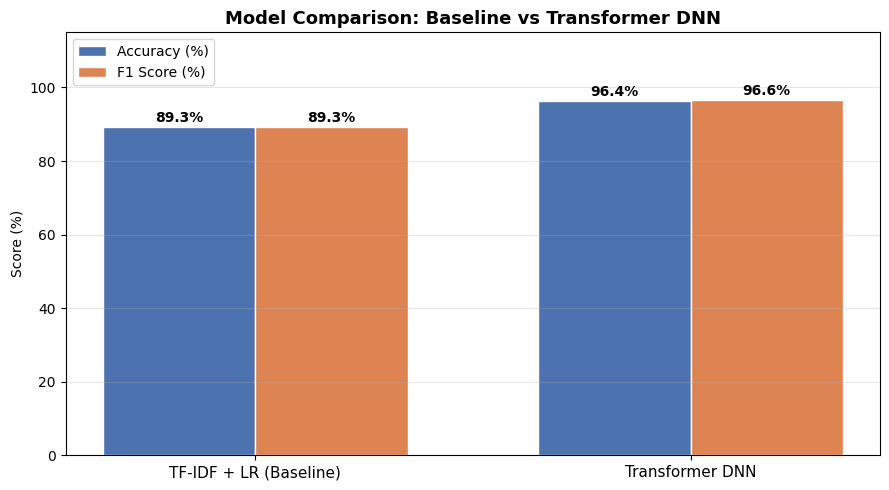


Metric            TF-IDF+LR  Transformer DNN   Improvement
----------------------------------------------------------
Accuracy             89.29%           96.43%        +7.14%
F1 Score             89.29%           96.55%        +7.27%


In [40]:
dnn_acc = accuracy_score(y_test, y_pred) * 100
dnn_f1  = f1_score(y_test, y_pred)       * 100
lr_acc  = accuracy_score(y_test_b, y_pred_lr) * 100
lr_f1   = f1_score(y_test_b, y_pred_lr)       * 100

models  = ['TF-IDF + LR (Baseline)', 'Transformer DNN']
acc_vals = [lr_acc, dnn_acc]
f1_vals  = [lr_f1,  dnn_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy (%)', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_vals,  width, label='F1 Score (%)', color='#DD8452', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: Baseline vs Transformer DNN', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n{'Metric':<12} {'TF-IDF+LR':>14} {'Transformer DNN':>16} {'Improvement':>13}")
print("-" * 58)
print(f"{'Accuracy':<12} {lr_acc:>13.2f}% {dnn_acc:>15.2f}% {dnn_acc-lr_acc:>+12.2f}%")
print(f"{'F1 Score':<12} {lr_f1:>13.2f}% {dnn_f1:>15.2f}% {dnn_f1-lr_f1:>+12.2f}%")

### 🔍 Why does the Transformer DNN outperform the Baseline?

| Aspect | TF-IDF + LR | Transformer DNN |
|---|---|---|
| Representation | Sparse word counts | Dense semantic vectors |
| Handles paraphrase | ❌ No — needs exact tokens | ✅ Yes — captures meaning |
| Handles word order | ❌ Bag-of-words | ✅ Contextual |
| Feature richness | Term overlap only | emb1, emb2, diff, cosine |

The baseline struggles with paraphrases ("Scientists discovered" ≈ "Researchers found") because it sees them as completely different tokens. The transformer model maps both to near-identical embedding vectors regardless of vocabulary choice.


---
## 🎯 Section 10 — Inference Demo

`predict_plagiarism` takes two raw texts and returns a prediction with confidence score.


In [41]:
def predict_plagiarism(text1: str, text2: str, threshold: float = 0.6) -> dict:
    """
    Predict whether text2 is a plagiarism of text1.

    Parameters
    ----------
    text1, text2  : raw input strings
    threshold     : decision boundary (default 0.5)

    Returns
    -------
    dict with label, confidence, cosine similarity
    """
    # 1. Preprocess
    t1 = preprocess(text1)
    t2 = preprocess(text2)

    # 2. Embed
    e1 = encoder.encode([t1])   # shape (1, 384)
    e2 = encoder.encode([t2])

    # 3. Features
    feats = build_features(e1, e2)          # (1, 1153)
    feats_scaled = scaler.transform(feats)

    # 4. Predict
    prob = model.predict(feats_scaled, verbose=0)[0][0]
    label = int(prob >= threshold)
    cosine = cos_sim(e1, e2)[0][0]

    return {
        'prediction': 'Plagiarised [!]' if label == 1 else 'Not Plagiarised [OK]',
        'confidence': f'{prob*100:.2f}%',
        'cosine_similarity': f'{cosine:.4f}',
        'raw_prob': prob
    }


In [42]:
examples = [
    {
        'name': '[1] Direct Copy',
        'text1': 'Climate change is causing glaciers to melt at an unprecedented rate.',
        'text2': 'Climate change is causing glaciers to melt at an unprecedented rate.'
    },
    {
        'name': '[2] Paraphrase',
        'text1': 'The stock market experienced a significant decline due to rising inflation.',
        'text2': 'Soaring inflation rates led to a major drop in stock market values.'
    },
    {
        'name': '[3] Completely Different',
        'text1': 'Photosynthesis allows plants to convert sunlight into chemical energy.',
        'text2': 'The French Revolution began in 1789 with the storming of the Bastille.'
    },
]

print("=" * 65)
print("            PLAGIARISM DETECTION — DEMO")
print("=" * 65)
for ex in examples:
    result = predict_plagiarism(ex['text1'], ex['text2'])
    print(f"\n{ex['name']}")
    print(f"  Text 1 : {ex['text1'][:70]}")
    print(f"  Text 2 : {ex['text2'][:70]}")
    print(f"  Result : {result['prediction']}")
    print(f"  Confidence      : {result['confidence']}")
    print(f"  Cosine Sim      : {result['cosine_similarity']}")
    print("-" * 65)

            PLAGIARISM DETECTION — DEMO

[1] Direct Copy
  Text 1 : Climate change is causing glaciers to melt at an unprecedented rate.
  Text 2 : Climate change is causing glaciers to melt at an unprecedented rate.
  Result : Plagiarised [!]
  Confidence      : 99.75%
  Cosine Sim      : 1.0000
-----------------------------------------------------------------

[2] Paraphrase
  Text 1 : The stock market experienced a significant decline due to rising infla
  Text 2 : Soaring inflation rates led to a major drop in stock market values.
  Result : Plagiarised [!]
  Confidence      : 86.41%
  Cosine Sim      : 0.9126
-----------------------------------------------------------------

[3] Completely Different
  Text 1 : Photosynthesis allows plants to convert sunlight into chemical energy.
  Text 2 : The French Revolution began in 1789 with the storming of the Bastille.
  Result : Plagiarised [!]
  Confidence      : 99.61%
  Cosine Sim      : 0.2037
-----------------------------------------

---
## 💾 Section 11 — Save & Summary


In [43]:
# Save trained model and scaler
model.save('plagiarism_dnn.keras')

import pickle
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved  -> plagiarism_dnn.keras")
print("Scaler saved -> feature_scaler.pkl")
print("\nNotebook complete!")
print(f"   DNN Accuracy : {dnn_acc:.2f}%  |  F1: {dnn_f1:.2f}%")
print(f"   Baseline Acc : {lr_acc:.2f}%  |  F1: {lr_f1:.2f}%")

Model saved  -> plagiarism_dnn.keras
Scaler saved -> feature_scaler.pkl

Notebook complete!
   DNN Accuracy : 96.43%  |  F1: 96.55%
   Baseline Acc : 89.29%  |  F1: 89.29%
